In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("CLEANED_JOB_MARKET_ANALYSIS.csv")
print(df.head())

   Job_ID       Job_Title       Company   Location   Salary  \
0     101    Data Analyst      TechCorp     Mumbai   600000   
1     102    Data Analyst  Innovate Ltd     Mumbai   720000   
2     103  Data Scientist      AI Works  Bangalore  1200000   
3     104    Data Analyst       Unknown      Delhi   800000   
4     105   Data Engineer      CloudNet       Pune  1000000   

  Experience_Required                     Skills Posted_Date   Job_Type  \
0           1-3 years         Python, SQL, Excel    5/1/2024  Full-time   
1             2 years                python, sql    5/3/2024  Full-time   
2           3-5 years  Python, ML, Deep Learning    5/4/2024  Full-time   
3              1 year                 Excel, SQL    5/6/2024  Full-time   
4           4-6 years      Python, Spark, Hadoop    5/7/2024  Full-time   

   Rating  
0    4.20  
1    4.00  
2    4.50  
3    4.05  
4    4.10  


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job_ID               20 non-null     int64  
 1   Job_Title            20 non-null     object 
 2   Company              20 non-null     object 
 3   Location             20 non-null     object 
 4   Salary               20 non-null     int64  
 5   Experience_Required  20 non-null     object 
 6   Skills               20 non-null     object 
 7   Posted_Date          20 non-null     object 
 8   Job_Type             20 non-null     object 
 9   Rating               20 non-null     float64
dtypes: float64(1), int64(2), object(7)
memory usage: 1.7+ KB
None
          Job_ID        Salary     Rating
count   20.00000  2.000000e+01  20.000000
mean   110.50000  7.380000e+05   4.032500
std      5.91608  3.326386e+05   0.451685
min    101.00000  2.000000e+05   2.500000
25%    105.75000  5.

In [ ]:
job_counts = df['Job_Title'].value_counts()
print(job_counts)

Job_Title
Data Analyst        12
Data Scientist       3
Data Engineer        2
Business Analyst     1
ML Engineer          1
Analyst              1
Name: count, dtype: int64


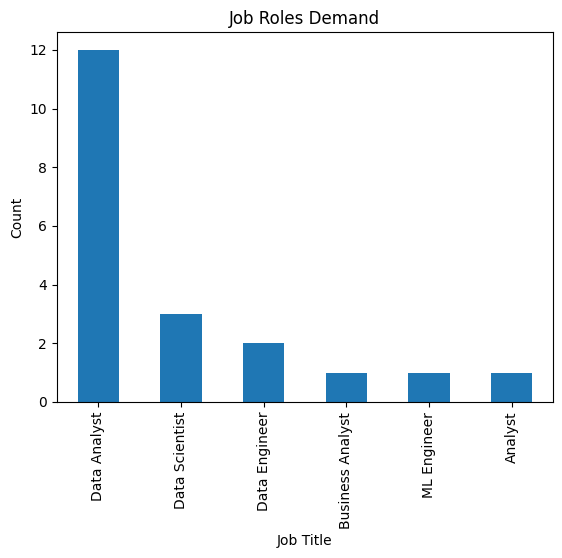

In [ ]:
job_counts.plot(kind='bar')
plt.title("Job Roles Demand")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.show()

In [ ]:
avg_salary = df.groupby('Job_Title')['Salary'].mean()
print(avg_salary)

Job_Title
Analyst             7.000000e+05
Business Analyst    7.000000e+05
Data Analyst        5.450000e+05
Data Engineer       1.050000e+06
Data Scientist      1.073333e+06
ML Engineer         1.500000e+06
Name: Salary, dtype: float64


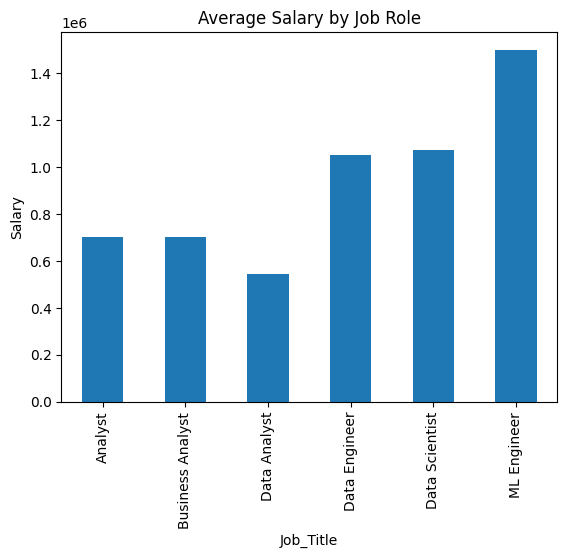

In [ ]:
avg_salary.plot(kind='bar')
plt.title("Average Salary by Job Role")
plt.ylabel("Salary")
plt.show()

In [ ]:
location_counts = df['Location'].value_counts()
print(location_counts)

Location
Mumbai       6
Bangalore    5
Delhi        2
Pune         2
Chennai      2
Unknown      1
Hyderabad    1
Remote       1
Name: count, dtype: int64


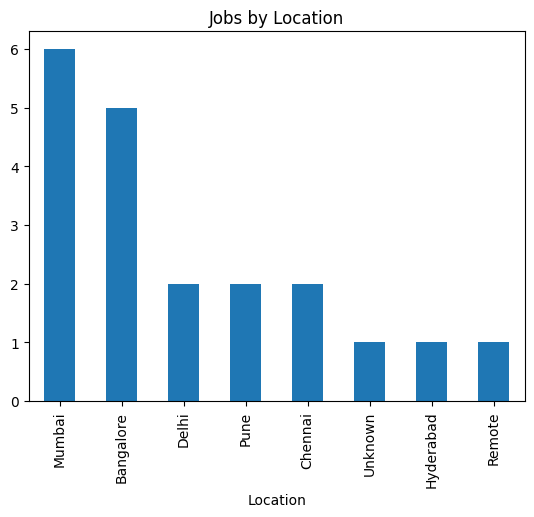

In [ ]:
location_counts.plot(kind='bar')
plt.title("Jobs by Location")
plt.show()

Skills
Excel            11
Python            9
SQL               8
ML                3
Hadoop            2
Spark             2
python            1
sql               1
Deep Learning     1
Power BI          1
NLP               1
Not Specified     1
Name: count, dtype: int64


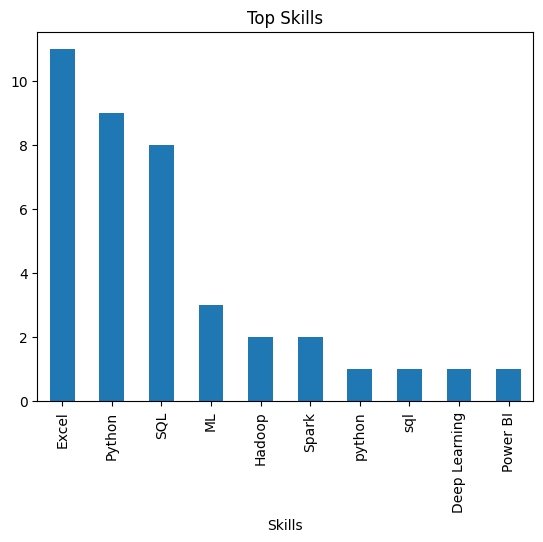

In [ ]:
skills_series = df['Skills'].str.split(', ').explode()
skills_count = skills_series.value_counts()

print(skills_count)
skills_count.head(10).plot(kind='bar')
plt.title("Top Skills")
plt.show()

Experience_Required
0.0     350000.0
1.0     620000.0
2.0     688000.0
3.0    1180000.0
4.0    1050000.0
Name: Salary, dtype: float64


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_10295/1765861280.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Experience_Required'] = df['Experience_Required'].str.extract('(\d+)').astype(float)


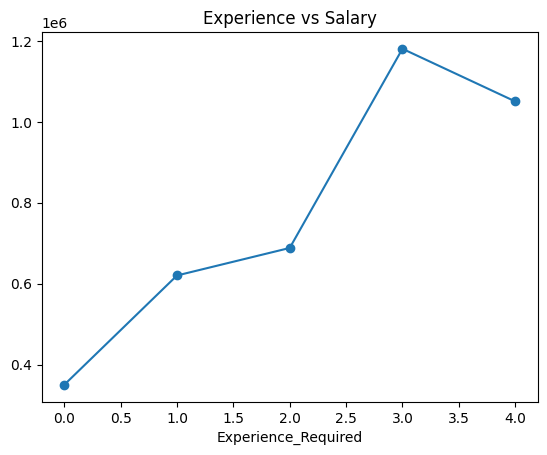

In [ ]:
df['Experience_Required'] = df['Experience_Required'].str.extract('(\d+)').astype(float)

exp_salary = df.groupby('Experience_Required')['Salary'].mean()
print(exp_salary)
exp_salary.plot(kind='line', marker='o')
plt.title("Experience vs Salary")
plt.show()

Job_Type
Full-time     15
Internship     3
Part-time      1
Contract       1
Name: count, dtype: int64


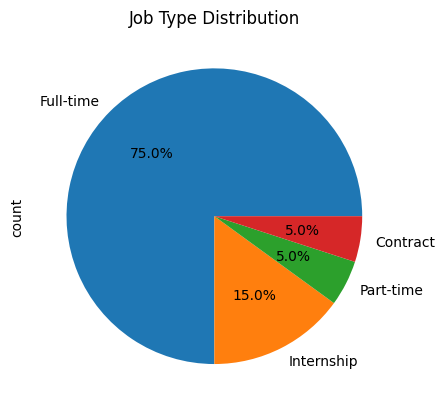

In [ ]:
job_type = df['Job_Type'].value_counts()
print(job_type)
job_type.plot(kind='pie', autopct='%1.1f%%')
plt.title("Job Type Distribution")
plt.show()

In [ ]:
top_jobs = df.sort_values(by='Salary', ascending=False)
print(top_jobs[['Job_Title', 'Company', 'Salary']].head())

         Job_Title   Company   Salary
9      ML Engineer  AI Works  1500000
16  Data Scientist  AI Works  1300000
2   Data Scientist  AI Works  1200000
13   Data Engineer  CloudNet  1100000
4    Data Engineer  CloudNet  1000000


In [ ]:
print(df.corr(numeric_only=True))

                       Job_ID    Salary  Experience_Required    Rating
Job_ID               1.000000 -0.235889            -0.189256 -0.383578
Salary              -0.235889  1.000000             0.821299  0.631692
Experience_Required -0.189256  0.821299             1.000000  0.469852
Rating              -0.383578  0.631692             0.469852  1.000000
